# Student Pass/Fail Prediction (Binary Classification)

This notebook trains and compares multiple ML models to predict `final_result` (0 = fail, 1 = pass) from exam marks.

It uses grouped splitting by `student_id` to avoid data leakage because each student appears in multiple subject rows.

In [ ]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import pickle

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

In [ ]:
RANDOM_SEED = 42
TEST_SIZE = 0.2

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "student_dataset_500_rows.csv"
OUTPUT_DIR = BASE_DIR / "artifacts"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "best_pass_fail_model.pkl"
METRICS_PATH = OUTPUT_DIR / "model_metrics.csv"
PROCESSED_PREVIEW_PATH = OUTPUT_DIR / "processed_preview.csv"

print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Data path: d:\ML Model\student_dataset_500_rows.csv
Output directory: D:\ML Model\artifacts


In [ ]:
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    print("Loaded existing dataset.")
else:
    print("Dataset not found. Creating a small synthetic fallback dataset.")
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []
    for sid in range(1000, 1050):
        for sub in ["Math", "Physics", "Chemistry", "Biology"]:
            marks = rng.integers(0, 101, size=19).tolist()
            final_result = int(np.mean(marks) >= 50)
            rows.append([sid, sub, *marks, final_result])
    columns = [
        "student_id", "subject",
        "ct_1", "ct_2", "ct_3", "ct_4", "ct_5", "ct_6", "ct_7", "ct_8", "ct_9", "ct_10", "ct_11", "ct_12",
        "term_1", "term_2", "term_3",
        "model_1", "model_2", "model_3", "model_4",
        "final_result"
    ]
    df = pd.DataFrame(rows, columns=columns)

print(df.shape)
df.head()

Loaded existing dataset.
(11540, 22)


,student_id,subject,ct_1,ct_2,ct_3,ct_4,ct_5,ct_6,ct_7,ct_8,ct_9,ct_10,ct_11,ct_12,term_1,term_2,term_3,model_1,model_2,model_3,model_4,final_result
0,1000,Math,35,61,41,88,37,35,70,39,32,58,37,34,39,40,48,39,40,36,48,0
1,1000,Physics,56,66,72,33,52,20,52,21,49,62,64,65,33,50,34,68,42,48,33,1
2,1000,Chemistry,47,78,83,39,16,65,58,82,57,56,49,57,64,35,69,54,51,47,71,1
3,1000,Biology,36,20,22,27,32,20,7,50,49,0,62,45,43,52,47,36,46,54,38,0
4,1001,Math,76,56,67,61,65,89,92,80,78,80,69,68,61,69,97,78,66,65,61,1


In [ ]:

def validate_dataset(data: pd.DataFrame) -> pd.DataFrame:
    required_cols = [
        "student_id", "subject",
        "ct_1", "ct_2", "ct_3", "ct_4", "ct_5", "ct_6", "ct_7", "ct_8", "ct_9", "ct_10", "ct_11", "ct_12",
        "term_1", "term_2", "term_3",
        "model_1", "model_2", "model_3", "model_4",
        "final_result",
    ]
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = data.copy()
    numeric_cols = [c for c in required_cols if c not in ["subject"]]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    score_cols = [c for c in data.columns if c.startswith("ct_") or c.startswith("term_") or c.startswith("model_")]
    data[score_cols] = data[score_cols].clip(lower=0, upper=100)
    data["final_result"] = data["final_result"].fillna(0).astype(int).clip(0, 1)

    data["subject"] = data["subject"].fillna("Unknown").astype(str)
    data["student_id"] = data["student_id"].astype(int)

    return data


def build_preprocessor(feature_cols: list[str]) -> ColumnTransformer:
    categorical_cols = ["subject"] if "subject" in feature_cols else []
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    numeric_transformer = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median"))]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop",
    )
    return preprocessor


def evaluate_model(model, X_train, y_train, X_test, y_test, name: str) -> dict:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        # fallback probability-like score for models without predict_proba
        score = model.decision_function(X_test)
        proba = (score - score.min()) / (score.max() - score.min() + 1e-9)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    }
    return metrics, pred

In [ ]:
clean_df = validate_dataset(df)

feature_cols = [c for c in clean_df.columns if c not in ["final_result"]]
# If stronger generalization to unseen IDs, drop it from feature_cols.
X = clean_df[feature_cols]
y = clean_df["final_result"]
groups = clean_df["student_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train pass rate:", y_train.mean().round(4), "Test pass rate:", y_test.mean().round(4))

preprocessor = build_preprocessor(feature_cols)

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=None,
        max_iter=300,
        random_state=RANDOM_SEED,
    ),
}

results = []
preds = {}
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    metrics, y_pred = evaluate_model(pipe, X_train, y_train, X_test, y_test, name)
    results.append(metrics)
    preds[name] = y_pred
    fitted_pipelines[name] = pipe

metrics_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
metrics_df

Train shape: (9232, 21) Test shape: (2308, 21)
Train pass rate: 0.5011 Test pass rate: 0.5364


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.975303,0.976594,0.977383,0.976988,0.993516
1,HistGradientBoosting,0.922877,0.934426,0.920840,0.927583,0.980431
2,RandomForest,0.914645,0.929810,0.909532,0.919559,0.973165


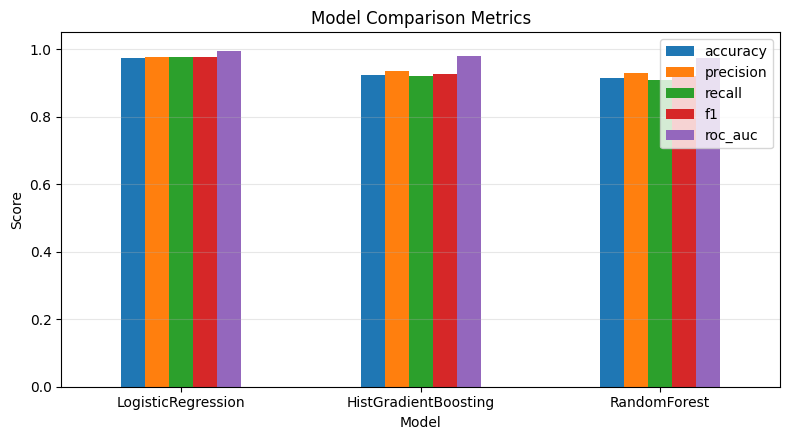

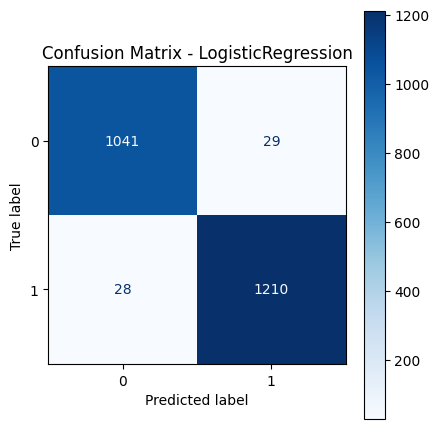

Best model by F1: LogisticRegression


,model,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.975303,0.976594,0.977383,0.976988,0.993516
1,HistGradientBoosting,0.922877,0.934426,0.920840,0.927583,0.980431
2,RandomForest,0.914645,0.929810,0.909532,0.919559,0.973165


In [6]:
# Section 6: Visualize Key Outputs
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = metrics_df.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Model Comparison Metrics")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_model_name = metrics_df.loc[0, "model"]
cm = confusion_matrix(y_test, preds[best_model_name])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(ax=ax, values_format="d", cmap="Blues")
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

print("Best model by F1:", best_model_name)
metrics_df

In [ ]:
best_model_name = metrics_df.loc[0, "model"]
best_pipeline = fitted_pipelines[best_model_name]

with open(MODEL_PATH, "wb") as f:
    pickle.dump(best_pipeline, f)

metrics_df.to_csv(METRICS_PATH, index=False)
clean_df.head(200).to_csv(PROCESSED_PREVIEW_PATH, index=False)

print(f"Saved best model: {MODEL_PATH}")
print(f"Saved metrics: {METRICS_PATH}")
print(f"Saved processed preview: {PROCESSED_PREVIEW_PATH}")

Saved best model: d:\ML Model\artifacts\best_pass_fail_model.pkl
Saved metrics: d:\ML Model\artifacts\model_metrics.csv
Saved processed preview: d:\ML Model\artifacts\processed_preview.csv
